In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import copy

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from PIL import Image
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from google.colab import drive

drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda
NVIDIA L4


In [19]:
SPLIT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/splits")

train_df = pd.read_csv(SPLIT_DIR / "train_split.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_split.csv")

print(train_df.head())
print(train_df["label"].value_counts())

        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  Non-Melanoma      0   
1  ISIC_0024308  IL_3692653                       Nevus  Non-Melanoma      0   
2  ISIC_0024309  IL_0959663                       Nevus  Non-Melanoma      0   
3  ISIC_0024310  IL_8194852               Melanoma, NOS      Melanoma      1   
4  ISIC_0024312  IL_3471258  Pigmented benign keratosis  Non-Melanoma      0   

                                          image_path  
0  /content/drive/MyDrive/bachelor_thesis_data/HA...  
1  /content/drive/MyDrive/bachelor_thesis_data/HA...  
2  /content/drive/MyDrive/bachelor_thesis_data/HA...  
3  /content/drive/MyDrive/bachelor_thesis_data/HA...  
4  /content/drive/MyDrive/bachelor_thesis_data/HA...  
label
0    7261
1     943
Name: count, dtype: int64


In [20]:
weights = EfficientNet_B0_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
import os
import numpy as np
import random

SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Improves reproducibility while warning instead of crashing
    # if an operation has no deterministic implementation.
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [22]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator()
generator.manual_seed(SEED)

In [23]:
!mkdir -p /content/HAM10000_images
!rsync -ah --info=progress2 /content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images/ /content/HAM10000_images/

              0   0%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/11722)


In [24]:
!find /content/HAM10000_images -type f | wc -l
!du -sh /content/HAM10000_images

11721
335M	/content/HAM10000_images


In [25]:
old_path = "/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images"
new_path = "/content/HAM10000_images"

train_df["image_path"] = train_df["image_path"].str.replace(old_path, new_path, regex=False)
val_df["image_path"] = val_df["image_path"].str.replace(old_path, new_path, regex=False)
test_df["image_path"] = test_df["image_path"].str.replace(old_path, new_path, regex=False)

print(train_df["image_path"].iloc[0])
print(Path(train_df["image_path"].iloc[0]).exists())

train_exists = train_df["image_path"].apply(lambda p: Path(p).exists())
val_exists = val_df["image_path"].apply(lambda p: Path(p).exists())
test_exists = test_df["image_path"].apply(lambda p: Path(p).exists())

print("Missing train images:", (~train_exists).sum())
print("Missing validation images:", (~val_exists).sum())
print("Missing test images:", (~test_exists).sum())

/content/HAM10000_images/ISIC_0024307.jpg
True
Missing train images: 0
Missing validation images: 0
Missing test images: 0


In [26]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [27]:
BATCH_SIZE = 32

train_dataset = MelanomaDataset(train_df, transform=train_transform)
val_dataset = MelanomaDataset(val_df, transform=val_test_transform)
test_dataset = MelanomaDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

In [28]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)

    return epoch_loss, all_labels, all_probs

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ----------------------------
# Recreate model from scratch
# ----------------------------

set_seed(SEED)
generator.manual_seed(SEED)

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ----------------------------
# Metric helper function
# ----------------------------

def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# ----------------------------
# Training settings
# ----------------------------

EPOCHS = 20

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

# ----------------------------
# Training loop
# ----------------------------

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

# ----------------------------
# Store history as dataframe
# ----------------------------

history_df = pd.DataFrame(history)

# ----------------------------
# Restore best model
# ----------------------------

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

# ----------------------------
# Save checkpoint and history
# ----------------------------

CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "baseline_seed42_best.pth"
)

history_df.to_csv(
    RESULTS_DIR / "baseline_seed42_training_history.csv",
    index=False
)

print("\nSaved:")
print(CHECKPOINT_DIR / "baseline_seed42_best.pth")
print(RESULTS_DIR / "baseline_seed42_training_history.csv")

# ----------------------------
# Final validation evaluation using best model
# ----------------------------

best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

best_val_preds = [1 if p >= 0.5 else 0 for p in best_val_probs]
best_cm = confusion_matrix(best_val_labels, best_val_preds)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_cm)

history_df


Epoch 1/20


100%|██████████| 55/55 [00:04<00:00, 11.53it/s]


Train loss: 0.2992
Val loss: 0.2275
Accuracy: 0.9030
Precision: 0.5909
Recall: 0.4041
F1-score: 0.4800
ROC-AUC: 0.8958
New best model saved.

Epoch 2/20


100%|██████████| 55/55 [00:04<00:00, 11.90it/s]


Train loss: 0.1743
Val loss: 0.2282
Accuracy: 0.9070
Precision: 0.5975
Recall: 0.4922
F1-score: 0.5398
ROC-AUC: 0.8992
New best model saved.

Epoch 3/20


...

100%|██████████| 55/55 [00:04<00:00, 11.95it/s]


Train loss: 0.0080
Val loss: 0.4918
Accuracy: 0.9168
Precision: 0.6644
Recall: 0.5026
F1-score: 0.5723
ROC-AUC: 0.8696

Training finished.
Best epoch: 10
Best validation F1-score: 0.6011

Saved:
/content/drive/MyDrive/bachelor_thesis_data/checkpoints/baseline_seed42_best.pth
/content/drive/MyDrive/bachelor_thesis_data/results/tables/baseline_seed42_training_history.csv


100%|██████████| 55/55 [00:04<00:00, 11.79it/s]


Best model validation results:
Val loss: 0.3862
Accuracy: 0.9162
Precision: 0.6358
Recall: 0.5699
F1-score: 0.6011
ROC-AUC: 0.8756
Confusion matrix:
[[1486   63]
 [  83  110]]


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.299176,0.227539,0.902985,0.590909,0.404145,0.480000,0.895835
1,2,0.174274,0.228232,0.907003,0.597484,0.492228,0.539773,0.899193
2,3,0.108217,0.244834,0.902411,0.564972,0.518135,0.540541,0.896617
3,4,0.070205,0.290973,0.904133,0.580247,0.487047,0.529577,0.881384
4,5,0.049691,0.346397,0.895522,0.529101,0.518135,0.523560,0.871018
5,6,0.038480,0.381602,0.888060,0.496124,0.663212,0.567627,0.888730
6,7,0.033052,0.385168,0.902411,0.559585,0.559585,0.559585,0.869384
7,8,0.024255,0.375309,0.913892,0.625731,0.554404,0.587912,0.875179
8,9,0.013749,0.424151,0.899541,0.540541,0.621762,0.578313,0.865178
9,10,0.018261,0.386179,0.916188,0.635838,0.569948,0.601093,0.875557


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
from pathlib import Path

# Evaluate best baseline model on test set
test_loss, test_labels, test_probs = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_preds = [1 if p >= 0.5 else 0 for p in test_probs]

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds, zero_division=0)
test_recall = recall_score(test_labels, test_preds, zero_division=0)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)
test_roc_auc = roc_auc_score(test_labels, test_probs)
test_cm = confusion_matrix(test_labels, test_preds)

print("Baseline test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion matrix:")
print(test_cm)

# Save test metrics
baseline_test_results = pd.DataFrame([{
    "experiment": "E1_real_imbalanced_baseline",
    "model": "EfficientNet-B0",
    "seed": SEED,
    "test_loss": test_loss,
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_roc_auc,
    "true_negatives": test_cm[0, 0],
    "false_positives": test_cm[0, 1],
    "false_negatives": test_cm[1, 0],
    "true_positives": test_cm[1, 1]
}])

RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_test_results.to_csv(
    RESULTS_DIR / "baseline_seed42_test_results.csv",
    index=False
)

baseline_test_results

100%|██████████| 56/56 [00:04<00:00, 12.41it/s]


Baseline test results:
Test loss: 0.3428
Accuracy: 0.9222
Precision: 0.6099
Recall: 0.5089
F1-score: 0.5548
ROC-AUC: 0.8772
Confusion matrix:
[[1550   55]
 [  83   86]]


,experiment,model,seed,test_loss,accuracy,precision,recall,f1,roc_auc,true_negatives,false_positives,false_negatives,true_positives
0,E1_real_imbalanced_baseline,EfficientNet-B0,42,0.342777,0.92221,0.609929,0.508876,0.554839,0.877211,1550,55,83,86


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.299176,0.227539,0.902985,0.590909,0.404145,0.480000,0.895835
1,2,0.174274,0.228232,0.907003,0.597484,0.492228,0.539773,0.899193
2,3,0.108217,0.244834,0.902411,0.564972,0.518135,0.540541,0.896617
3,4,0.070205,0.290973,0.904133,0.580247,0.487047,0.529577,0.881384
4,5,0.049691,0.346397,0.895522,0.529101,0.518135,0.523560,0.871018
5,6,0.038480,0.381602,0.888060,0.496124,0.663212,0.567627,0.888730
6,7,0.033052,0.385168,0.902411,0.559585,0.559585,0.559585,0.869384
7,8,0.024255,0.375309,0.913892,0.625731,0.554404,0.587912,0.875179
8,9,0.013749,0.424151,0.899541,0.540541,0.621762,0.578313,0.865178
9,10,0.018261,0.386179,0.916188,0.635838,0.569948,0.601093,0.875557


Lowest validation loss:
Epoch 1, val_loss = 0.2275

Highest validation F1-score:
Epoch 10, F1 = 0.6011


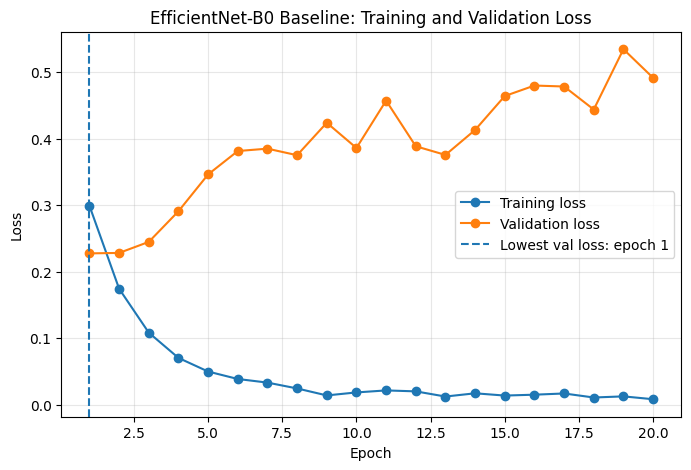

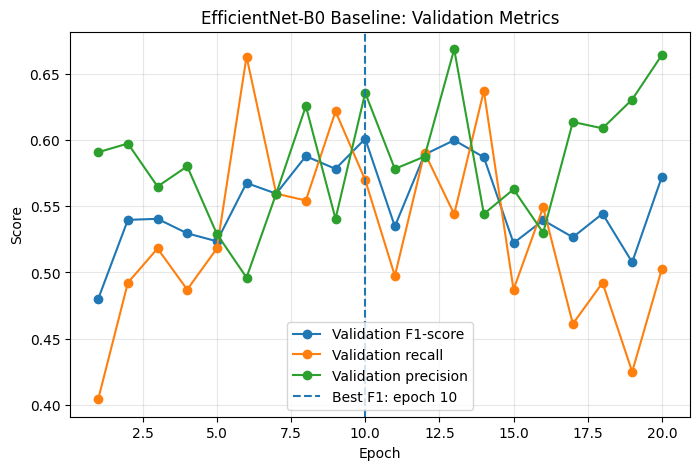

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load saved training history
HISTORY_PATH = "/content/drive/MyDrive/bachelor_thesis_data/results/tables/baseline_seed42_training_history.csv"

history_df = pd.read_csv(HISTORY_PATH)

display(history_df)

# Find best epoch according to validation loss
best_val_loss_idx = history_df["val_loss"].idxmin()
best_val_loss_epoch = int(history_df.loc[best_val_loss_idx, "epoch"])
best_val_loss = history_df.loc[best_val_loss_idx, "val_loss"]

# Find best epoch according to validation F1-score
best_f1_idx = history_df["f1"].idxmax()
best_f1_epoch = int(history_df.loc[best_f1_idx, "epoch"])
best_f1 = history_df.loc[best_f1_idx, "f1"]

print("Lowest validation loss:")
print(f"Epoch {best_val_loss_epoch}, val_loss = {best_val_loss:.4f}")

print("\nHighest validation F1-score:")
print(f"Epoch {best_f1_epoch}, F1 = {best_f1:.4f}")

# Create figure directory
FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")

plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Lowest val loss: epoch {best_val_loss_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Baseline: Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "baseline_seed42_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Plot validation metrics
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["f1"], marker="o", label="Validation F1-score")
plt.plot(history_df["epoch"], history_df["recall"], marker="o", label="Validation recall")
plt.plot(history_df["epoch"], history_df["precision"], marker="o", label="Validation precision")

plt.axvline(
    best_f1_epoch,
    linestyle="--",
    label=f"Best F1: epoch {best_f1_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("EfficientNet-B0 Baseline: Validation Metrics")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "baseline_seed42_validation_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

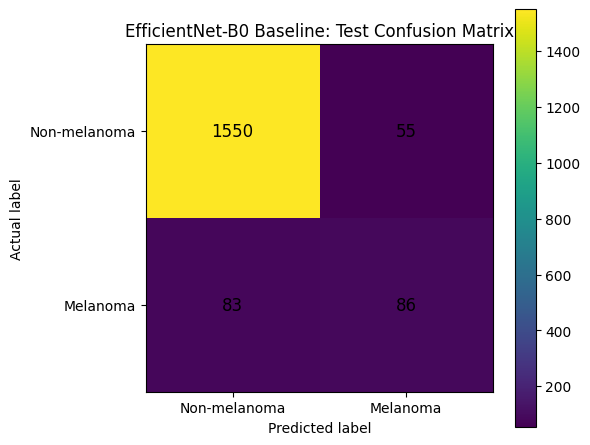

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Baseline test confusion matrix
# Rows = actual labels, columns = predicted labels
cm = np.asarray(test_cm)

class_names = ["Non-melanoma", "Melanoma"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("EfficientNet-B0 Baseline: Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURE_DIR / "baseline_seed42_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()